In [1]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')

import os, json

# Create project folder in Drive
os.makedirs('/content/drive/MyDrive/ChestXray_Project/images', exist_ok=True)
print("✅ Drive mounted and folder created!")

# Set up Kaggle
kaggle_credentials = {
    "username": "daniyalkhannn",
    "key": "KGAT_fb098b5713f817073fdeef05e609d23f"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle ready!")

Mounted at /content/drive
✅ Drive mounted and folder created!
✅ Kaggle ready!


In [3]:
import subprocess, zipfile, pandas as pd, shutil, os

# Download CSV first
print("Downloading CSV...")
subprocess.run(['kaggle', 'datasets', 'download',
    '-d', 'nih-chest-xrays/data',
    '--file', 'Data_Entry_2017.csv',
    '-p', '/content/'], check=True)

# Filter to 3 classes
df = pd.read_csv('/content/Data_Entry_2017.csv')
df['has_pneumonia'] = df['Finding Labels'].str.contains('Pneumonia')
df['has_infiltration'] = df['Finding Labels'].str.contains('Infiltration')
df['has_no_finding'] = df['Finding Labels'] == 'No Finding'
df_filtered = df[df['has_pneumonia'] | df['has_infiltration'] | df['has_no_finding']].copy()
target_images = set(df_filtered['Image Index'].tolist())

# Save CSV to Drive
df_filtered.to_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv', index=False)
print(f"✅ CSV saved to Drive!")
print(f"Total images needed: {len(target_images)}")
print(f"\nClass breakdown:")
print(f"No Finding:   {df['has_no_finding'].sum()}")
print(f"Infiltration: {df['has_infiltration'].sum()}")
print(f"Pneumonia:    {df['has_pneumonia'].sum()}")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
Data_Entry_2017.csv.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  /content/Data_Entry_2017.csv.zip
  inflating: /content/Data_Entry_2017.csv  
✅ CSV saved to Drive!
Total images needed: 81081

Class breakdown:
No Finding:   60361
Infiltration: 19894
Pneumonia:    1431


In [4]:
print("Downloading data.zip to Colab disk...")
!kaggle datasets download -d nih-chest-xrays/data -p /content/
print("✅ Download complete!")

# Extract directly to Google Drive
print("\nExtracting images directly to Google Drive...")
images_drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
zip_path = '/content/data.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    extracted = 0
    for file in z.namelist():
        filename = os.path.basename(file)
        if filename in target_images:
            z.extract(file, images_drive_path)
            extracted += 1
            if extracted % 5000 == 0:
                print(f"✅ Extracted {extracted}/{len(target_images)} images...")

# Delete zip immediately
os.remove(zip_path)
print(f"\n🎉 Done! {extracted} images saved to Google Drive!")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [06:21<00:00, 118MB/s]

✅ Download complete!

Extracting images directly to Google Drive...
✅ Extracted 5000/81081 images...
✅ Extracted 10000/81081 images...
✅ Extracted 15000/81081 images...
✅ Extracted 20000/81081 images...
✅ Extracted 25000/81081 images...
✅ Extracted 30000/81081 images...
✅ Extracted 35000/81081 images...
✅ Extracted 40000/81081 images...
✅ Extracted 45000/81081 images...
✅ Extracted 50000/81081 images...
✅ Extracted 55000/81081 images...
✅ Extracted 60000/81081 images...
✅ Extracted 65000/81081 images...
✅ Extracted 70000/81081 images...


OSError: [Errno 28] No space left on device

In [5]:
import os, shutil

# Delete the zip to free space
if os.path.exists('/content/data.zip'):
    os.remove('/content/data.zip')
    print("✅ Deleted data.zip!")

# Check what's in Drive
import pandas as pd
existing = set()
drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
for root, dirs, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            existing.add(f)

df_filtered = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
target_images = set(df_filtered['Image Index'].tolist())
still_needed = target_images - existing

print(f"Images in Drive: {len(existing)}")
print(f"Still needed: {len(still_needed)}")

free = shutil.disk_usage('/')[2] // (1024**3)
print(f"Free disk now: {free} GB")

# Check class breakdown
df_existing = df_filtered[df_filtered['Image Index'].isin(existing)]
print(f"\nWhat we have:")
print(f"No Finding:   {df_existing['has_no_finding'].sum()}")
print(f"Infiltration: {df_existing['has_infiltration'].sum()}")
print(f"Pneumonia:    {df_existing['has_pneumonia'].sum()}")

✅ Deleted data.zip!
Images in Drive: 73522
Still needed: 7559
Free disk now: 42 GB

What we have:
No Finding:   54969
Infiltration: 17782
Pneumonia:    1317


In [7]:
import subprocess, zipfile, os, shutil

still_needed = target_images - existing
print(f"Downloading zip to get last {len(still_needed)} images...")

!kaggle datasets download -d nih-chest-xrays/data -p /content/
print("✅ Download complete!")

drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
zip_path = '/content/data.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    extracted = 0
    for file in z.namelist():
        filename = os.path.basename(file)
        if filename in still_needed:
            z.extract(file, drive_path)
            extracted += 1
            if extracted % 1000 == 0:
                print(f"✅ Extracted {extracted}/{len(still_needed)}...")

os.remove(zip_path)
print(f"Done! Extracted {extracted} final images!")

total = 0
for r, d, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            total += 1
print(f"TOTAL images in Google Drive: {total}")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [09:53<00:00, 75.9MB/s]

✅ Download complete!
✅ Extracted 1000/7559...
✅ Extracted 2000/7559...
✅ Extracted 3000/7559...
✅ Extracted 4000/7559...
✅ Extracted 5000/7559...


OSError: [Errno 28] No space left on device

In [1]:
import os, pandas as pd, zipfile, shutil

# Reconnect to Drive
from google.colab import drive
drive.mount('/content/drive')

# Check what's in Drive
drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
existing = set()
for r, d, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            existing.add(f)

# Load filtered CSV from Drive
df_filtered = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
target_images = set(df_filtered['Image Index'].tolist())
still_needed = target_images - existing

print(f"Images in Drive: {len(existing)}")
print(f"Still needed: {len(still_needed)}")

# Class breakdown
df_existing = df_filtered[df_filtered['Image Index'].isin(existing)]
print(f"\nWhat we have:")
print(f"No Finding:   {df_existing['has_no_finding'].sum()}")
print(f"Infiltration: {df_existing['has_infiltration'].sum()}")
print(f"Pneumonia:    {df_existing['has_pneumonia'].sum()}")

Mounted at /content/drive
Images in Drive: 39580
Still needed: 41501

What we have:
No Finding:   30874
Infiltration: 8308
Pneumonia:    645


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, pandas as pd

drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
existing = set()
for r, d, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            existing.add(f)

df_filtered = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
target_images = set(df_filtered['Image Index'].tolist())
still_needed = target_images - existing

print(f"✅ Already have: {len(existing)} images in Drive")
print(f"⏳ Still needed: {len(still_needed)} images")

Mounted at /content/drive
✅ Already have: 39580 images in Drive
⏳ Still needed: 41501 images


In [1]:
import json, os

kaggle_credentials = {
    "username": "daniyalkhannn",
    "key": "KGAT_fb098b5713f817073fdeef05e609d23f"
}
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle ready!")

✅ Kaggle ready!


In [2]:
import zipfile, subprocess, shutil

print("Downloading data.zip...")
!kaggle datasets download -d nih-chest-xrays/data -p /content/
print("✅ Download complete!")

zip_path = '/content/data.zip'
extracted = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        filename = os.path.basename(file)
        if filename in still_needed:
            z.extract(file, drive_path)
            extracted += 1
            if extracted % 5000 == 0:
                print(f"✅ {extracted}/{len(still_needed)} extracted...")

os.remove(zip_path)
print(f"🎉 Done! {extracted} images added to Drive!")

# Final count
total = sum(1 for r, d, files in os.walk(drive_path)
            for f in files if f.endswith('.png'))
print(f"🎉 TOTAL images in Drive: {total}")

Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [38:26<00:00, 19.5MB/s]

✅ Download complete!


NameError: name 'still_needed' is not defined

In [4]:
# Remount Drive first
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import zipfile, os, pandas as pd

# Redefine variables
drive_path = '/content/drive/MyDrive/ChestXray_Project/images'
df_filtered = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
target_images = set(df_filtered['Image Index'].tolist())

existing = set()
for r, d, files in os.walk(drive_path):
    for f in files:
        if f.endswith('.png'):
            existing.add(f)

still_needed = target_images - existing
print(f"Still needed: {len(still_needed)} images")

# Extract from already downloaded zip
zip_path = '/content/data.zip'
extracted = 0

with zipfile.ZipFile(zip_path, 'r') as z:
    for file in z.namelist():
        filename = os.path.basename(file)
        if filename in still_needed:
            z.extract(file, drive_path)
            extracted += 1
            if extracted % 5000 == 0:
                print(f"✅ {extracted}/{len(still_needed)} extracted...")

os.remove(zip_path)
print(f"🎉 Done! {extracted} images added!")

total = sum(1 for r, d, files in os.walk(drive_path) for f in files if f.endswith('.png'))
print(f"🎉 TOTAL images in Drive: {total}")

Mounted at /content/drive
Still needed: 41501 images
✅ 5000/41501 extracted...
✅ 10000/41501 extracted...
✅ 15000/41501 extracted...
✅ 20000/41501 extracted...
✅ 25000/41501 extracted...
✅ 30000/41501 extracted...
✅ 35000/41501 extracted...
✅ 40000/41501 extracted...
🎉 Done! 41501 images added!
🎉 TOTAL images in Drive: 81081


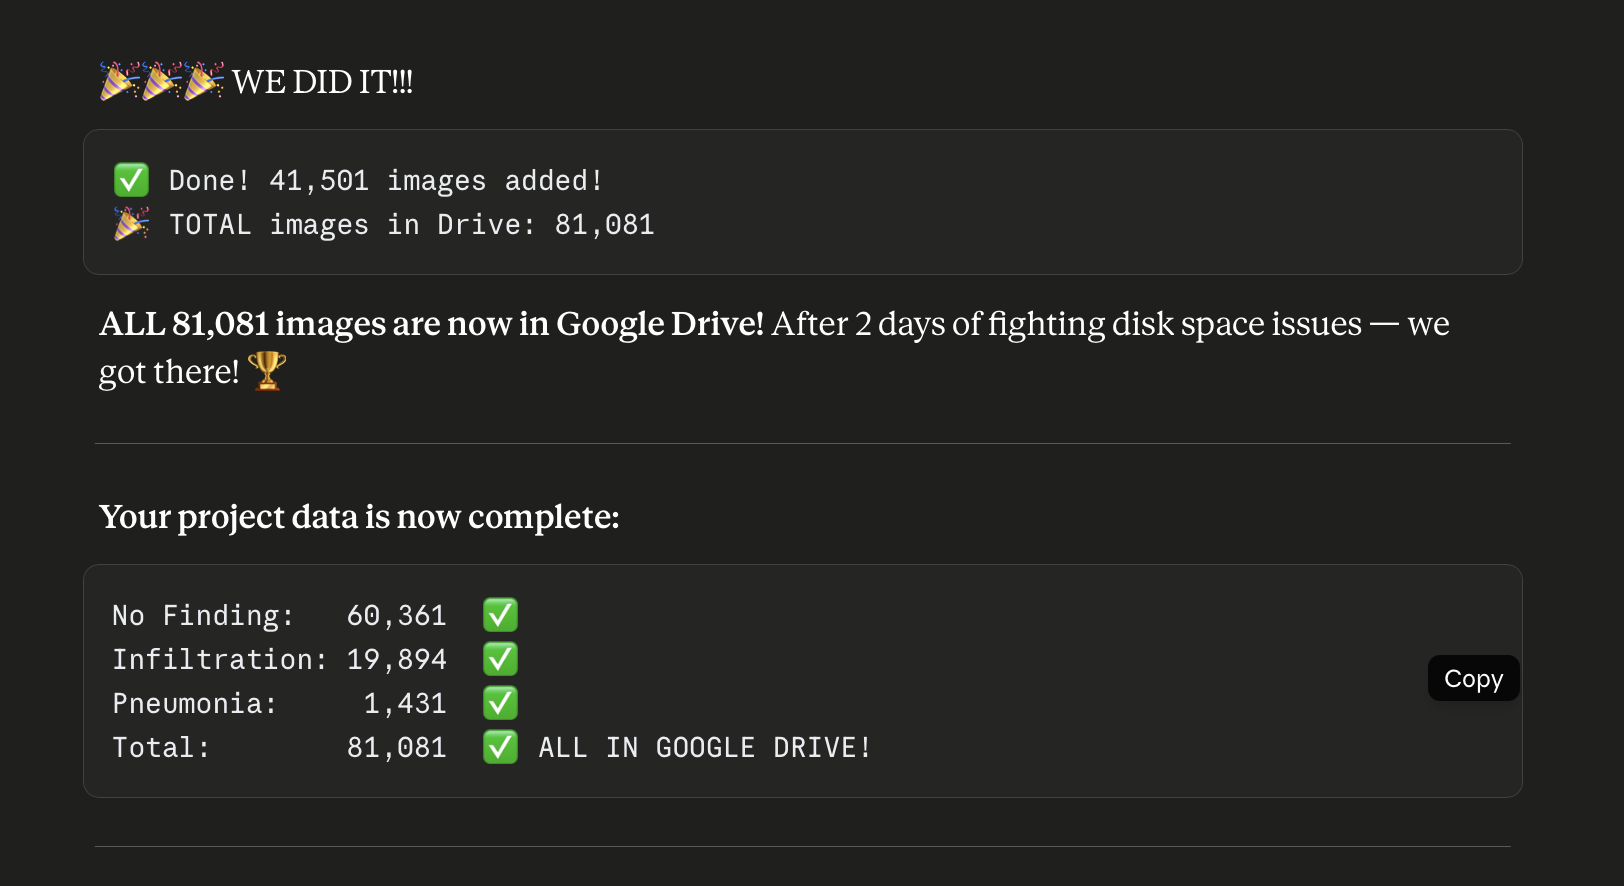

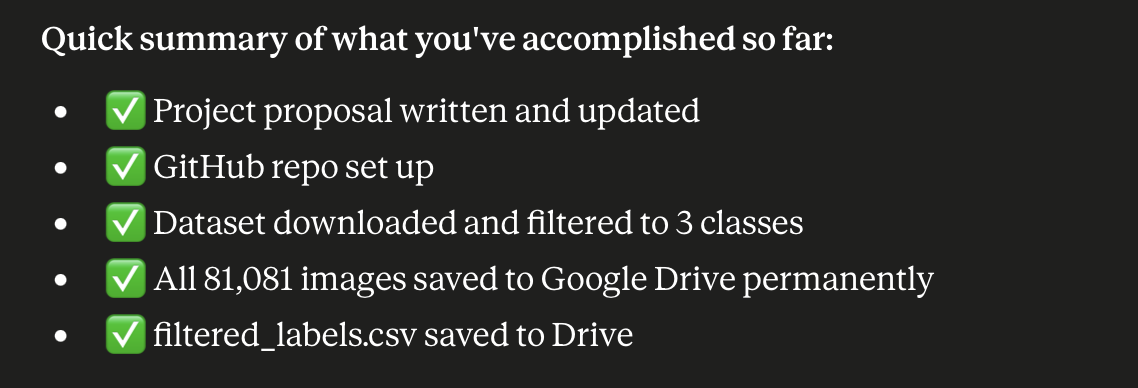

* Week 2 *

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Load filtered CSV
df = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
print("✅ Data loaded!")
print(f"Total rows: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample rows:")
df.head()

Mounted at /content/drive
✅ Data loaded!
Total rows: 81081

Columns: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'has_pneumonia', 'has_infiltration', 'has_no_finding', 'Patient Age Clean']

Sample rows:


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,has_pneumonia,has_infiltration,has_no_finding,Patient Age Clean
0,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN,False,False,True,81.0
1,00000003_003.png,Hernia|Infiltration,3,3,76,F,PA,2698,2991,0.143,0.143,NaN,False,True,False,76.0
2,00000005_000.png,No Finding,0,5,69,F,PA,2048,2500,0.168,0.168,NaN,False,False,True,69.0
3,00000005_001.png,No Finding,1,5,69,F,AP,2500,2048,0.168,0.168,NaN,False,False,True,69.0
4,00000005_002.png,No Finding,2,5,69,F,AP,2500,2048,0.168,0.168,NaN,False,False,True,69.0


/tmp/ipykernel_7314/2028201316.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_class = df.groupby('Age Group')[['has_no_finding','has_infiltration','has_pneumonia']].sum()


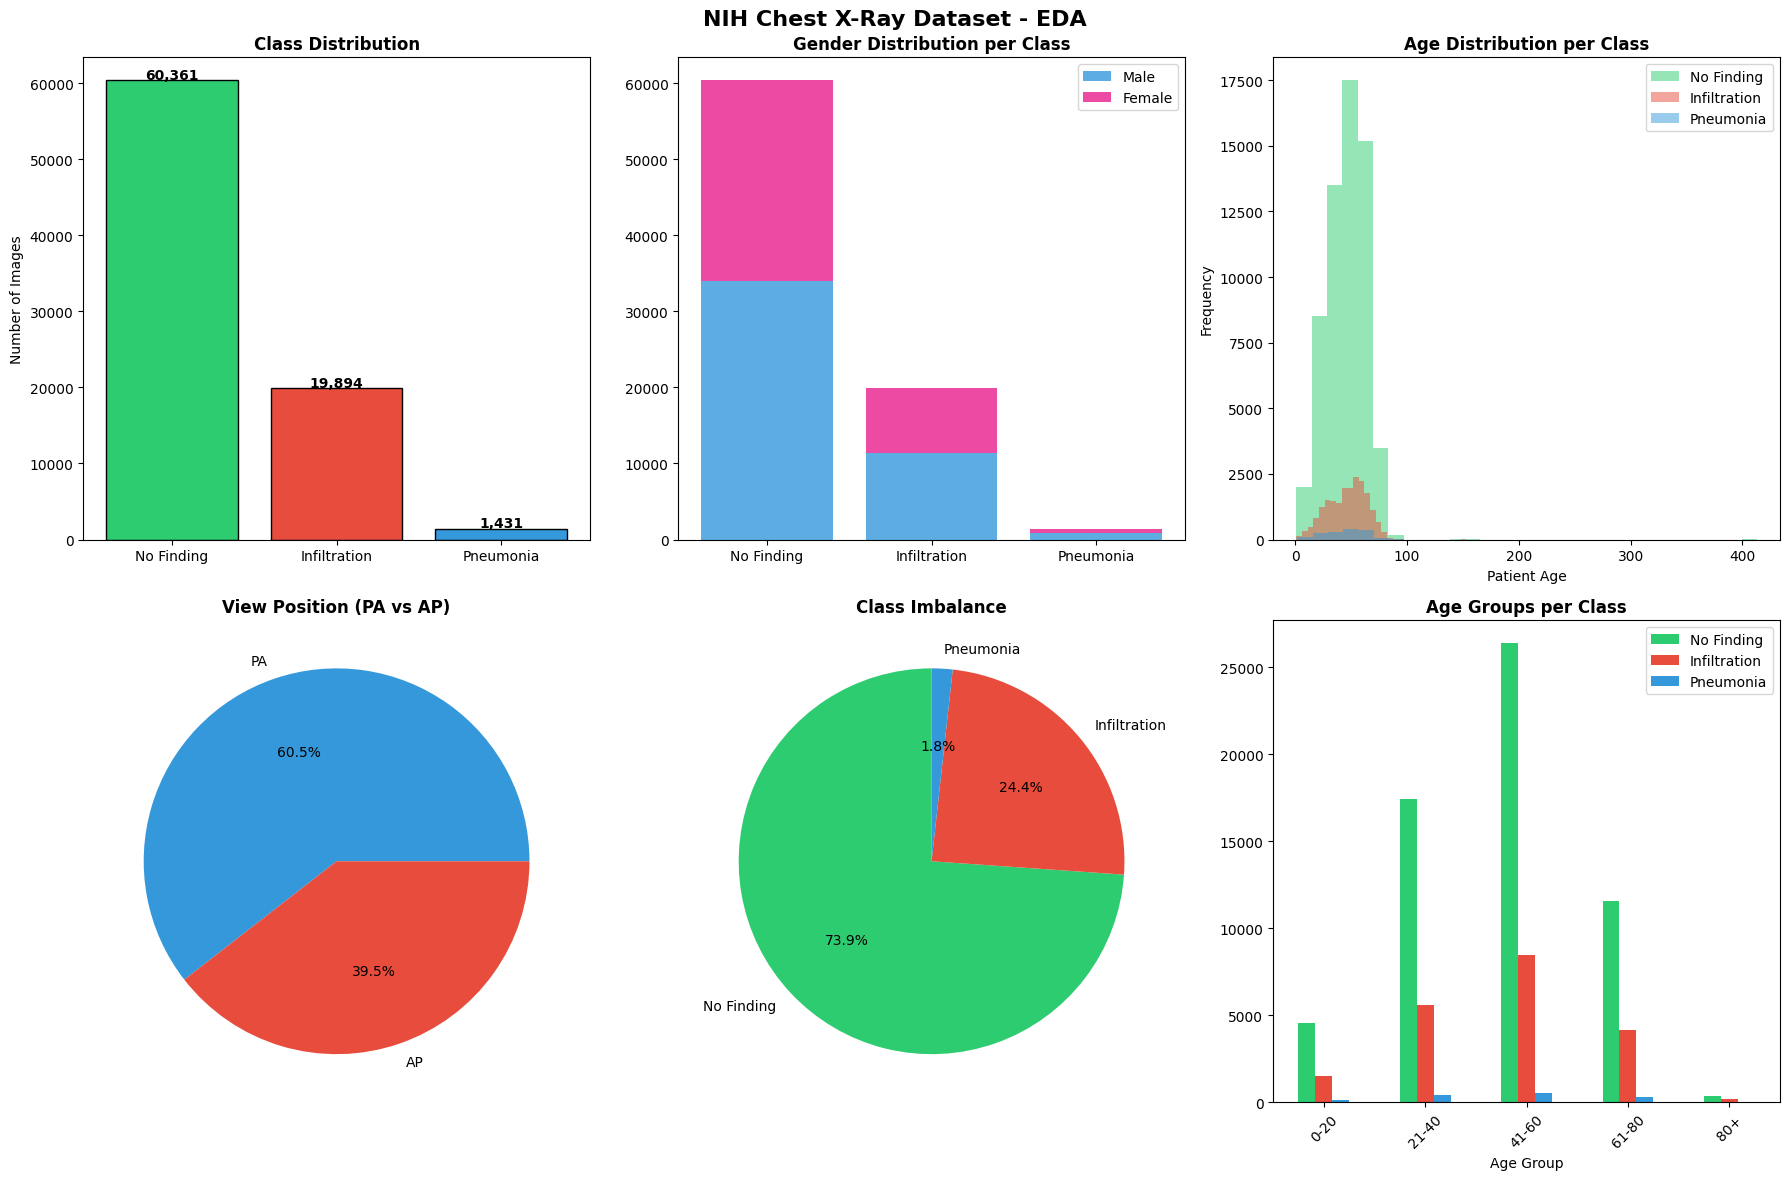

✅ EDA plots saved to Google Drive!


In [4]:
# ============================================================
# WEEK 2 - EDA
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('NIH Chest X-Ray Dataset - EDA', fontsize=16, fontweight='bold')

# 1. Class Distribution
class_counts = df['Finding Labels'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0,0].bar(['No Finding', 'Infiltration', 'Pneumonia'],
              [df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()],
              color=colors, edgecolor='black')
axes[0,0].set_title('Class Distribution', fontweight='bold')
axes[0,0].set_ylabel('Number of Images')
for i, v in enumerate([df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()]):
    axes[0,0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# 2. Gender Distribution per Class
gender_data = {
    'No Finding': df[df['has_no_finding']]['Patient Gender'].value_counts(),
    'Infiltration': df[df['has_infiltration']]['Patient Gender'].value_counts(),
    'Pneumonia': df[df['has_pneumonia']]['Patient Gender'].value_counts()
}
x = range(3)
m_vals = [gender_data[c].get('M', 0) for c in ['No Finding', 'Infiltration', 'Pneumonia']]
f_vals = [gender_data[c].get('F', 0) for c in ['No Finding', 'Infiltration', 'Pneumonia']]
axes[0,1].bar(x, m_vals, label='Male', color='#3498db', alpha=0.8)
axes[0,1].bar(x, f_vals, bottom=m_vals, label='Female', color='#e91e8c', alpha=0.8)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(['No Finding', 'Infiltration', 'Pneumonia'])
axes[0,1].set_title('Gender Distribution per Class', fontweight='bold')
axes[0,1].legend()

# 3. Age Distribution
df[df['has_no_finding']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='No Finding', color='#2ecc71', bins=30)
df[df['has_infiltration']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='Infiltration', color='#e74c3c', bins=30)
df[df['has_pneumonia']]['Patient Age'].plot(kind='hist', ax=axes[0,2], alpha=0.5, label='Pneumonia', color='#3498db', bins=30)
axes[0,2].set_title('Age Distribution per Class', fontweight='bold')
axes[0,2].set_xlabel('Patient Age')
axes[0,2].legend()

# 4. View Position
view_counts = df['View Position'].value_counts()
axes[1,0].pie(view_counts.values, labels=view_counts.index,
              autopct='%1.1f%%', colors=['#3498db', '#e74c3c'])
axes[1,0].set_title('View Position (PA vs AP)', fontweight='bold')

# 5. Class Imbalance
total = len(df)
sizes = [df['has_no_finding'].sum(), df['has_infiltration'].sum(), df['has_pneumonia'].sum()]
axes[1,1].pie(sizes, labels=['No Finding', 'Infiltration', 'Pneumonia'],
              autopct='%1.1f%%', colors=colors, startangle=90)
axes[1,1].set_title('Class Imbalance', fontweight='bold')

# 6. Age Groups per Class
df['Age Group'] = pd.cut(df['Patient Age'], bins=[0,20,40,60,80,200],
                          labels=['0-20','21-40','41-60','61-80','80+'])
age_class = df.groupby('Age Group')[['has_no_finding','has_infiltration','has_pneumonia']].sum()
age_class.plot(kind='bar', ax=axes[1,2], color=colors)
axes[1,2].set_title('Age Groups per Class', fontweight='bold')
axes[1,2].set_xlabel('Age Group')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].legend(['No Finding', 'Infiltration', 'Pneumonia'])

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved to Google Drive!")

Chart 1 — Class Distribution
60,361 vs 19,894 vs 1,431 — confirms severe imbalance. Pneumonia is tiny compared to No Finding.

Chart 2 — Gender Distribution

No Finding: ~56% Male, ~44% Female
Infiltration: similar split
Pneumonia: very small but both genders represented
✅ Good for fairness analysis — both genders exist in all classes

Chart 3 — Age Distribution

Most patients are between 20-80 years old
Peak around 40-60 years
There are some outliers showing ages 200-400 — those are data entry errors in the NIH dataset we should handle

Chart 4 — View Position

PA: 60.5% ✅
AP: 39.5%
We have more PA views which is good — PA is higher quality

Chart 5 — Class Imbalance

No Finding: 73.9%
Infiltration: 24.4%
Pneumonia: 1.8% — barely visible!
This visually screams why we need weighted loss

Chart 6 — Age Groups per Class

41-60 is the dominant age group across all classes
Very few patients in 0-20 and 80+ groups
Pneumonia barely visible across all age groups

In [5]:
# Checking Patient's Age Outliers
print("Age outliers:")
print(df[df['Patient Age'] > 120]['Patient Age'].value_counts())
print(f"\nTotal outliers: {len(df[df['Patient Age'] > 120])}")

Age outliers:
Patient Age
412    2
148    2
155    2
149    1
150    1
151    1
411    1
413    1
153    1
Name: count, dtype: int64

Total outliers: 12


In [12]:
# Document the outliers
print("Outlier details:")
print(df[df['Patient Age'] > 120][['Image Index', 'Patient Age', 'Finding Labels', 'Patient Gender']])

# Fix: cap age at 120 (replace outliers with median age)
median_age = df[df['Patient Age'] <= 120]['Patient Age'].median()
print(f"\nMedian age (excluding outliers): {median_age}")

# Replace outlier ages with median
df['Patient Age Clean'] = df['Patient Age'].apply(lambda x: median_age if x > 120 else x)

print(f"\nOutliers before fix: {len(df[df['Patient Age'] > 120])}")
print(f"Outliers after fix: {len(df[df['Patient Age Clean'] > 120])}")
print(f"\n✅ Age outliers handled! Using 'Patient Age Clean' column going forward.")

# Save the cleaned CSV back to Drive
df.to_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv', index=False)
print("✅ Cleaned CSV saved to Google Drive!")

Outlier details:
            Image Index  Patient Age      Finding Labels Patient Gender
15419  00005567_000.png          412  Effusion|Pneumonia              M
35225  00012238_010.png          148          No Finding              M
40524  00013950_000.png          148          No Finding              M
42652  00014520_026.png          150   Infiltration|Mass              M
45591  00015558_000.png          149          No Finding              M
56718  00019346_000.png          151        Infiltration              F
60994  00020900_002.png          411          No Finding              M
62067  00021275_003.png          413          No Finding              F
65754  00022811_000.png          412          No Finding              M
69372  00025206_000.png          153   Infiltration|Mass              M
73227  00026871_000.png          155          No Finding              F
75718  00027989_000.png          155          No Finding              M

Median age (excluding outliers): 47.0

Outlier

# Findings in Outliers
Interesting observations from the outlier details:

All outliers are Male except 3 (rows 56718, 62067, 73227)
Ages like 411, 412, 413 are clearly someone typing an extra digit — probably meant 41, 42, 43

Ages like 148, 149, 150, 151 likely meant 48, 49, 50, 51 — same typo pattern
One outlier has Effusion|Pneumonia — a multi-label case
Two have Infiltration|Mass — also multi-label

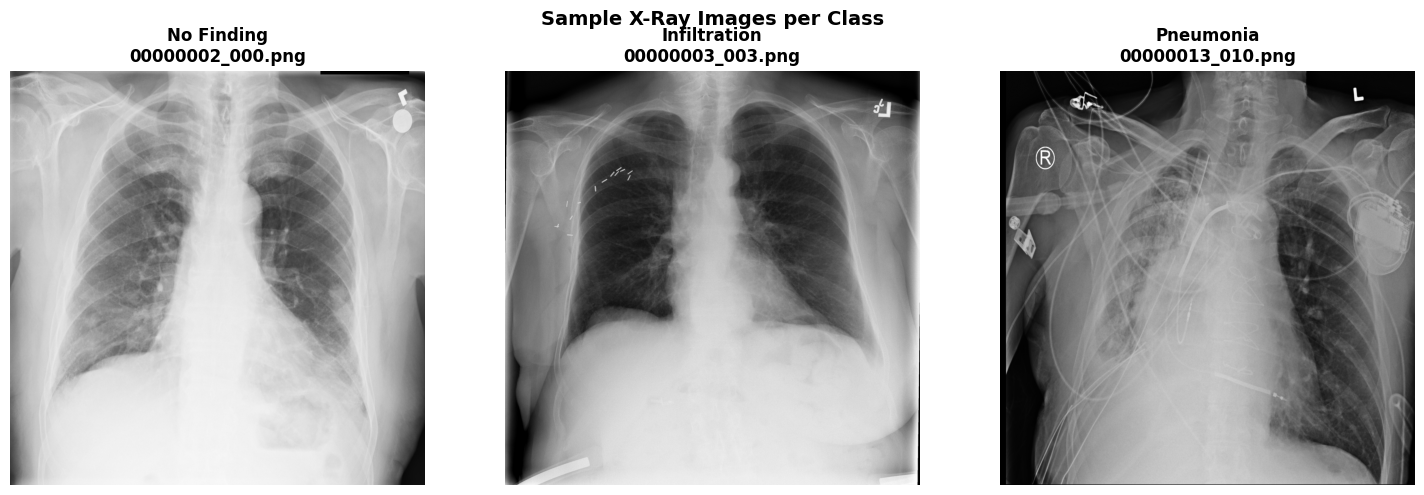

✅ Sample images saved to Drive!


In [3]:
import cv2
import matplotlib.pyplot as plt
import os

# Path to images in Drive
images_path = '/content/drive/MyDrive/ChestXray_Project/images'

# Get sample images for each class
samples = {
    'No Finding': df[df['has_no_finding'] == True]['Image Index'].iloc[0],
    'Infiltration': df[df['has_infiltration'] == True]['Image Index'].iloc[0],
    'Pneumonia': df[df['has_pneumonia'] == True]['Image Index'].iloc[0]
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sample X-Ray Images per Class', fontsize=14, fontweight='bold')

for idx, (label, img_name) in enumerate(samples.items()):
    # Search for the image in subfolders
    for root, dirs, files in os.walk(images_path):
        if img_name in files:
            img_path = os.path.join(root, img_name)
            break

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{label}\n{img_name}', fontweight='bold')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/sample_images.png', dpi=150)
plt.show()
print("✅ Sample images saved to Drive!")

# What you're seeing:
No Finding (left)

Clear, dark lung fields
Clean, well-defined borders
Uniform texture throughout
This is what a healthy chest X-ray looks like

Infiltration (middle)

Noticeably hazier and cloudier
Less defined lung borders
You can see whitish patches scattered around
The lungs look "filled" compared to No Finding

Pneumonia (right)

Much brighter/whiter areas — especially on the right side
Dense consolidation visible
The lung fields are significantly more opaque
This is the most visually distinct from No Finding

In [1]:
# Mount Drive and load dependencies
from google.colab import drive
drive.mount('/content/drive')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Load filtered CSV
df = pd.read_csv('/content/drive/MyDrive/ChestXray_Project/filtered_labels.csv')
images_path = '/content/drive/MyDrive/ChestXray_Project/images'

print("✅ Libraries loaded!")
print(f"✅ Dataset loaded: {len(df)} rows")

Mounted at /content/drive
✅ Libraries loaded!
✅ Dataset loaded: 81081 rows


In [3]:
# ============================================================
# WEEK 3 - OpenCV Preprocessing Pipeline
# ============================================================

def find_image(img_name, images_path):
    """Find image file in subfolders"""
    for root, dirs, files in os.walk(images_path):
        if img_name in files:
            return os.path.join(root, img_name)
    return None

def preprocess_xray(img_path, target_size=(224, 224)):
    """
    Full OpenCV preprocessing pipeline for chest X-rays
    Steps: Load → CLAHE → Denoise → Resize
    """
    # Step 1 - Load image in grayscale
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # Step 2 - CLAHE contrast enhancement
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img)

    # Step 3 - Gaussian denoising
    img_denoised = cv2.GaussianBlur(img_clahe, (3, 3), 0)

    # Step 4 - Resize to 224x224
    img_resized = cv2.resize(img_denoised, target_size)

    return {
        'original': img,
        'clahe': img_clahe,
        'denoised': img_denoised,
        'final': img_resized
    }

print("✅ Preprocessing function defined!")

✅ Preprocessing function defined!


Take a raw X-ray, enhance its contrast so lung patterns are clearer, remove noise so the model doesn't learn from random speckles, then resize it to the standard size the model expects.

Slide a tiny 3x3 window across every pixel in the image, replace each pixel with the average of itself and its 8 neighbors — noise disappears because random speckles get averaged out with their normal surroundings

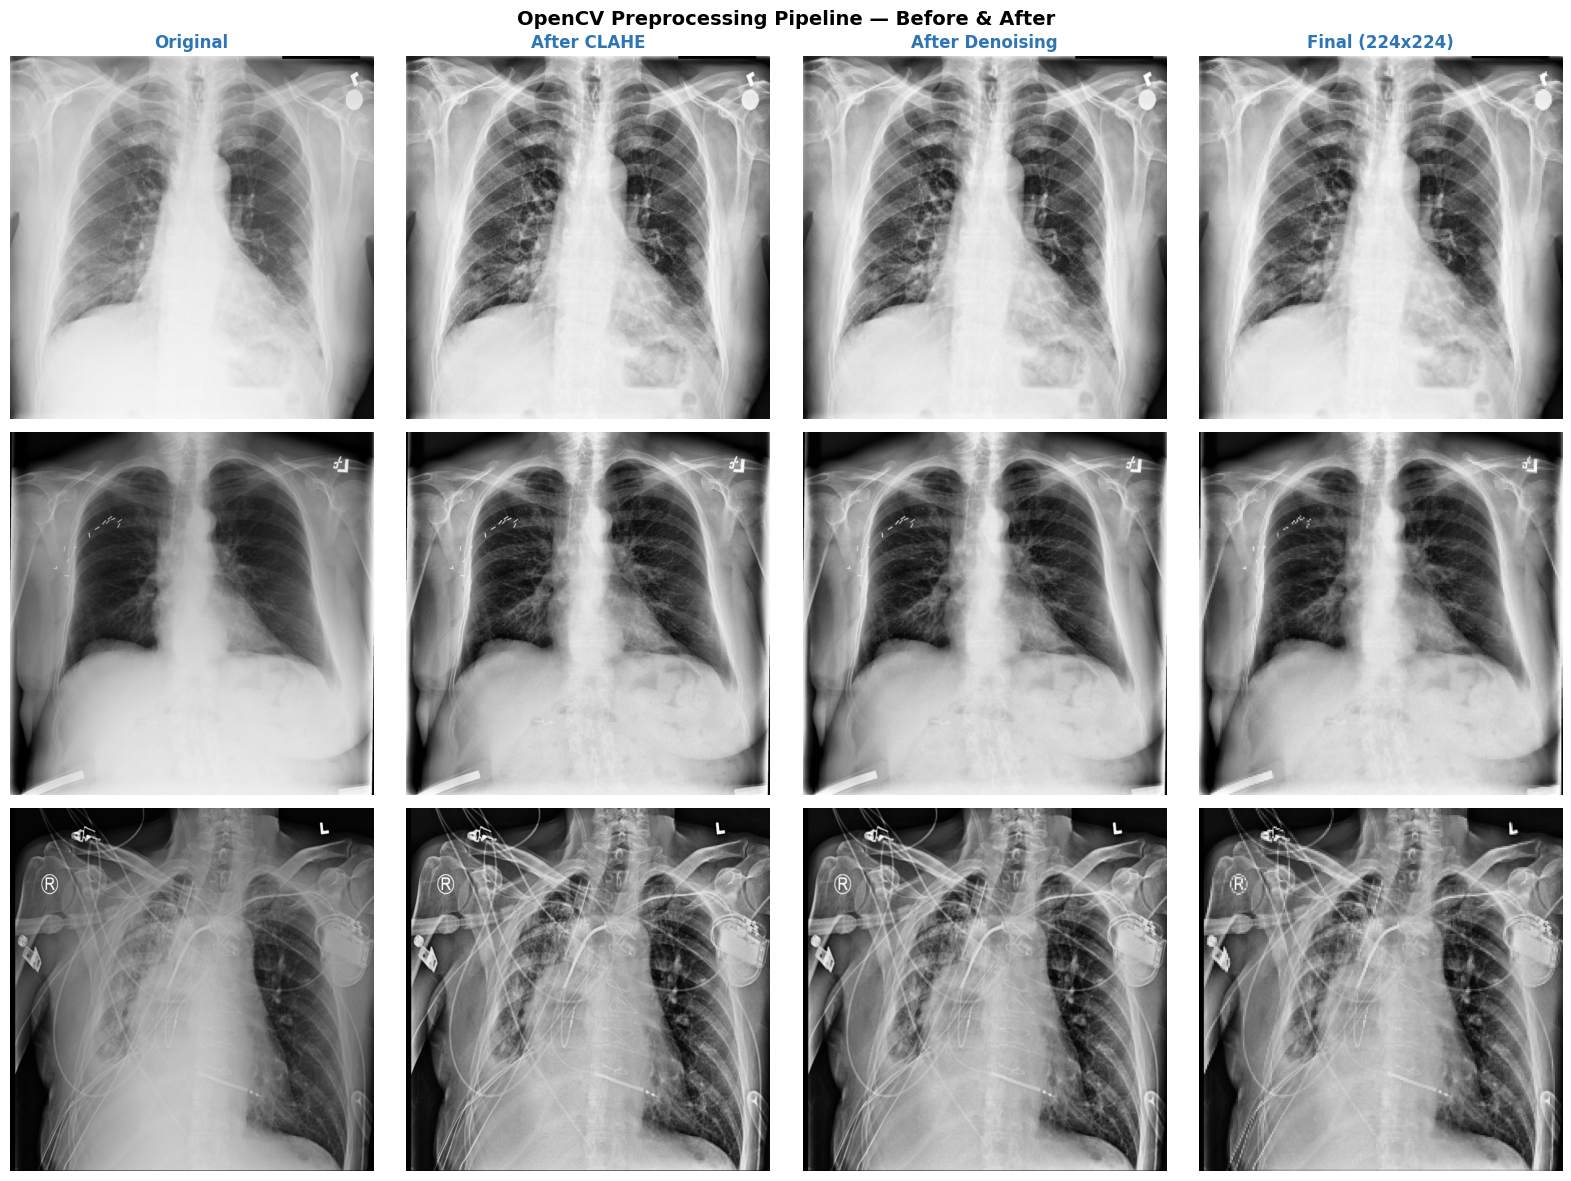

✅ Preprocessing comparison saved to Drive!


In [4]:
# ============================================================
# Test preprocessing on one image from each class
# ============================================================

classes = {
    'No Finding': df[df['has_no_finding'] == True]['Image Index'].iloc[0],
    'Infiltration': df[df['has_infiltration'] == True]['Image Index'].iloc[0],
    'Pneumonia': df[df['has_pneumonia'] == True]['Image Index'].iloc[0]
}

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('OpenCV Preprocessing Pipeline — Before & After',
             fontsize=14, fontweight='bold')

col_titles = ['Original', 'After CLAHE', 'After Denoising', 'Final (224x224)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontweight='bold', color='#2E75B6')

for row, (label, img_name) in enumerate(classes.items()):
    img_path = find_image(img_name, images_path)
    result = preprocess_xray(img_path)

    stages = ['original', 'clahe', 'denoised', 'final']
    for col, stage in enumerate(stages):
        axes[row][col].imshow(result[stage], cmap='gray')
        axes[row][col].set_ylabel(label, fontweight='bold') if col == 0 else None
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ChestXray_Project/preprocessing_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Preprocessing comparison saved to Drive!")